# Football Player Salary Prediction\n### Using Machine Learning on FIFA Attributes, Match Statistics & Market Values

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# Load data from SQLite database
conn = sqlite3.connect('data/football_data.db')

salaries = pd.read_sql("SELECT * FROM salaries", conn)
sofifa = pd.read_sql("SELECT * FROM sofifa_attributes", conn)
stats = pd.read_sql("SELECT * FROM player_stats", conn)
market = pd.read_sql("SELECT * FROM market_values", conn)

conn.close()

# Merge tables on player_pk (drop duplicate id columns before merge)
sofifa = sofifa.drop(columns=['id', 'player_id', 'short_name', 'long_name', 'player_url', 'fifa_version', 'fifa_update',
       'fifa_update_date',], errors='ignore')
print(f"Sofifa columns after dropping: {sofifa.columns}")
stats = stats.drop(columns=['id', 'player_name'], errors='ignore')
print(f"Stats columns after dropping: {stats.columns}")
market = market.drop(columns=['id'], errors='ignore')
print(f"Market columns after dropping: {market.columns}")

df = salaries.merge(sofifa, on='player_pk', how='left', suffixes=('', '_sofifa'))
df = df.merge(stats, on='player_pk', how='left', suffixes=('', '_stats'))
df = df.merge(market, on='player_pk', how='left', suffixes=('', '_market'))

# Filter: salary > 0, appearances >= 20, league_level in (1, 2)
df = df[df['gross_annual_eur'] > 0]
df = df[df['appearances'] >= 20]
df = df[df['league_name'].isin(['Premier League', 'La Liga', 'Serie A', 'Bundesliga', 'Ligue 1'])]

df.drop(columns=['weekly_wage_eur','player_id', 'gross_weekly_eur', 'api_football_id'], inplace=True, errors='ignore')
print(f"Dataset shape after filtering: {df.shape}")
print(f"Players: {df.shape[0]}, Features: {df.shape[1]}")
print(f"\nColumns: {list(df.columns)}")
print(df['release_clause_eur'].head())
df.head(3)

Sofifa columns after dropping: Index(['player_pk', 'player_positions', 'overall', 'potential', 'value_eur',
       'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg',
       ...
       'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb', 'gk',
       'player_face_url'],
      dtype='str', length=104)
Stats columns after dropping: Index(['player_pk', 'api_football_id', 'season', 'league_id', 'league_name',
       'club_id', 'club_name', 'position', 'age', 'nationality', 'appearances',
       'lineups', 'minutes', 'rating', 'goals', 'assists', 'shots_total',
       'shots_on', 'passes_total', 'passes_key', 'passes_accuracy', 'tackles',
       'interceptions', 'blocks', 'duels_total', 'duels_won',
       'dribbles_attempted', 'dribbles_success', 'fouls_drawn',
       'fouls_committed', 'yellow_cards', 'red_cards', 'penalties_scored',
       'penalties_missed'],
      dtype='str')
Market columns after dropping: Index(['player_pk', 'sofifa_id', 'tm_player_id', 'tm_player_name',
       'tm_p

,id,player_pk,short_name,long_name,cap_player_name,cap_player_url,gross_annual_eur,annual_salary_display,cap_club,cap_league,cap_position,cap_age,cap_country,contract_expiry,match_method,match_score,scrape_date,player_positions,overall,potential,age,dob,height_cm,weight_kg,league_id,...,interceptions,blocks,duels_total,duels_won,dribbles_attempted,dribbles_success,fouls_drawn,fouls_committed,yellow_cards,red_cards,penalties_scored,penalties_missed,sofifa_id,tm_player_id,tm_player_name,tm_player_url,tm_league,tm_league_code,tm_club,tm_nationality,tm_position,tm_age,market_value_eur,market_value_display,scrape_date_market
2,3,348,W. Saliba,William Alain André Gabriel Saliba,William Saliba,https://www.capology.com/player/william-saliba...,15060128.0,"£ 13,000,000",Arsenal,direct,,24,,"Sep 30, 2025",player_url,1.0,2026-03-31,CB,87.0,89.0,24.0,2001-03-24,193.0,85.0,13.0,...,14.0,4.0,191.0,108.0,7.0,4.0,15.0,17.0,1.0,0.0,0.0,0.0,243715.0,495666.0,William Saliba,https://www.transfermarkt.com/william-saliba/p...,Premier League,GB1,Arsenal FC,France,Centre-Back,25.0,90000000.0,€90.00m,2026-03-31
4,5,344,D. Rice,Declan Rice,Declan Rice,https://www.capology.com/player/declan-rice-36...,14457723.0,"£ 12,480,000",Arsenal,direct,,27,,"Jul 15, 2023",long_name,1.0,2026-03-31,"CDM, CM",87.0,88.0,26.0,1999-01-14,185.0,80.0,13.0,...,30.0,11.0,198.0,121.0,25.0,12.0,8.0,20.0,2.0,0.0,0.0,0.0,234378.0,357662.0,Declan Rice,https://www.transfermarkt.com/declan-rice/prof...,Premier League,GB1,Arsenal FC,England,Central Midfield,41.0,120000000.0,€120.00m,2026-03-31
5,6,345,V. Gyökeres,Viktor Einar Gyökeres,Viktor Gyökeres,https://www.capology.com/player/viktor-gyokere...,12048102.0,"£ 10,400,000",Arsenal,direct,,27,,"Jul 26, 2025",player_url,1.0,2026-03-31,ST,87.0,88.0,27.0,1998-06-04,189.0,94.0,13.0,...,1.0,2.0,192.0,59.0,32.0,6.0,23.0,28.0,4.0,0.0,2.0,0.0,241651.0,325443.0,Viktor Gyökeres,https://www.transfermarkt.com/viktor-gyokeres/...,Premier League,GB1,Arsenal FC,Sweden,Centre-Forward,27.0,65000000.0,€65.00m,2026-03-31


## Exploratory Data Analysis

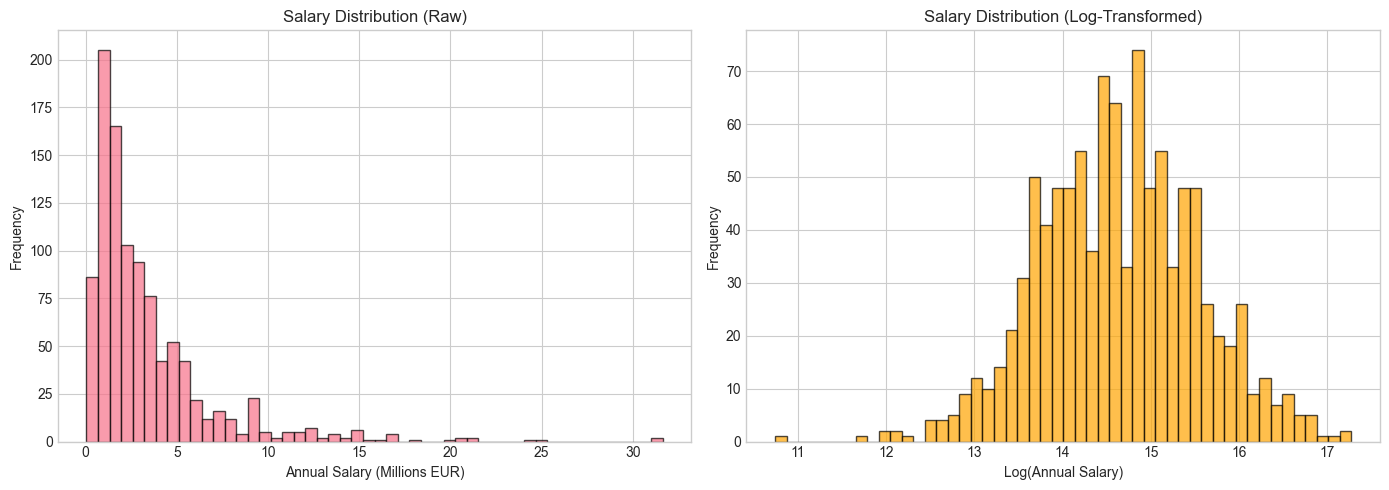

count         €1,008
mean      €3,373,049
std       €3,571,192
min          €46,338
25%       €1,204,810
50%       €2,180,000
75%       €4,181,709
max      €31,626,269
Name: gross_annual_eur, dtype: str


In [27]:
# Salary Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['gross_annual_eur'] / 1e6, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Annual Salary (Millions EUR)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Salary Distribution (Raw)')

axes[1].hist(np.log1p(df['gross_annual_eur']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Log(Annual Salary)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Salary Distribution (Log-Transformed)')

plt.tight_layout()
plt.savefig('figures/salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['gross_annual_eur'].describe().apply(lambda x: f"€{x:,.0f}"))

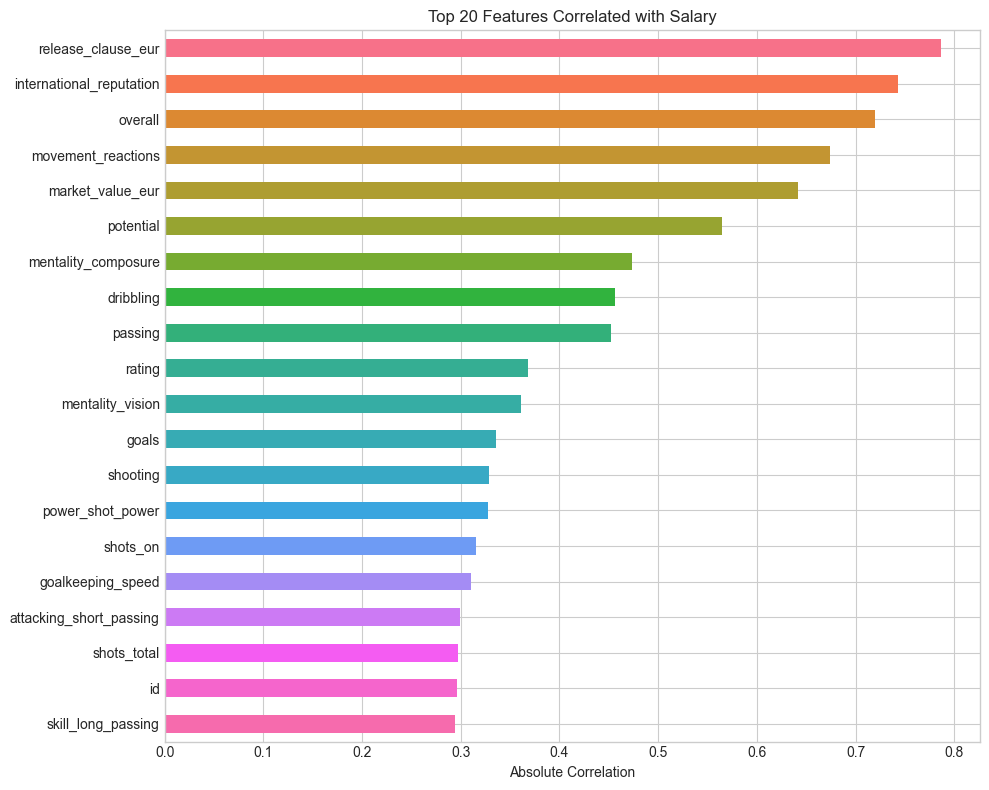

In [28]:
# Top 20 Feature Correlations with Salary
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_salary = df[numeric_cols].corr()['gross_annual_eur'].drop('gross_annual_eur').abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_salary.plot(kind='barh', ax=ax, color=sns.color_palette('husl', 20))
ax.set_xlabel('Absolute Correlation')
ax.set_title('Top 20 Features Correlated with Salary')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/top_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

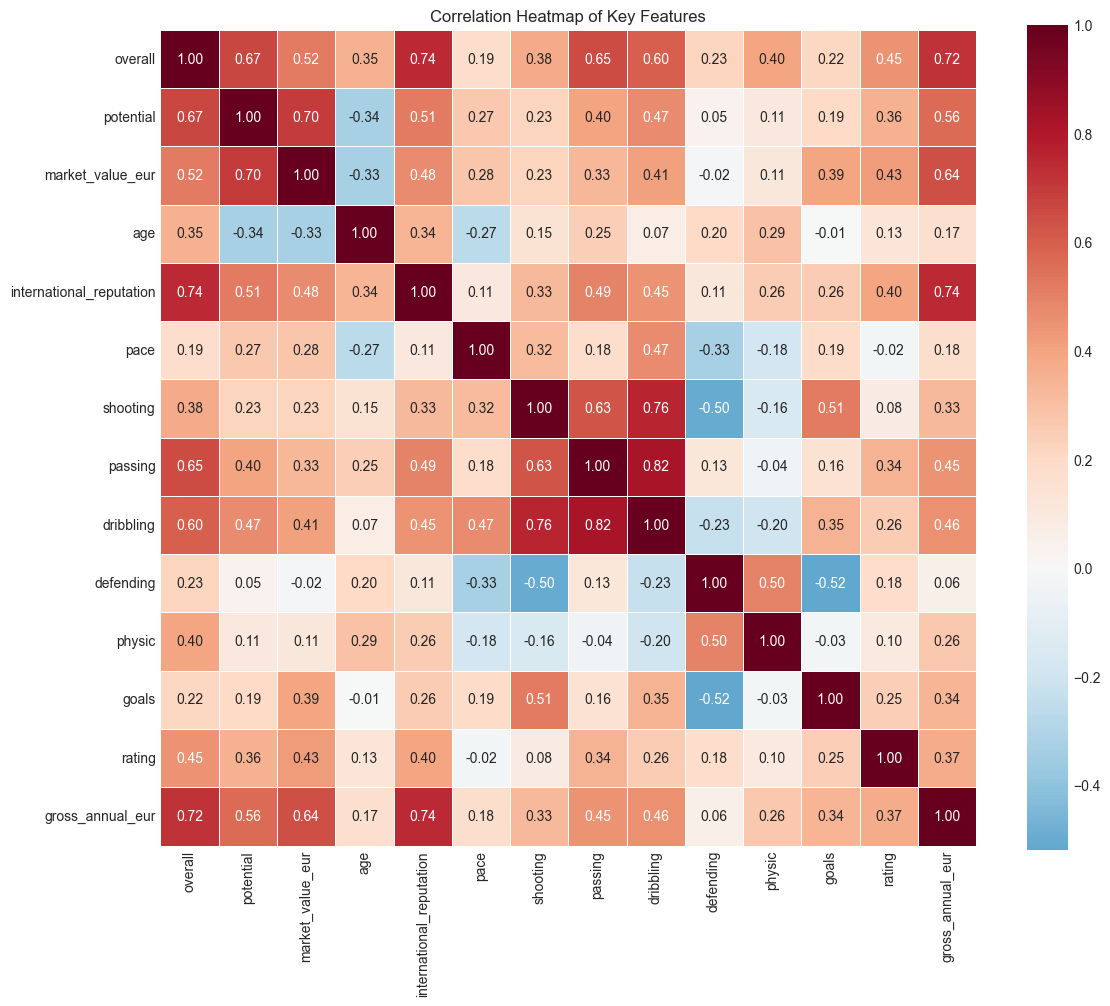

In [29]:
# Correlation Heatmap of Key Features
key_features = ['overall', 'potential', 'value_eur', 'wage_eur', 'market_value_eur',
                'age', 'international_reputation', 'pace', 'shooting', 'passing',
                'dribbling', 'defending', 'physic', 'goals', 'rating', 'gross_annual_eur']
key_features = [f for f in key_features if f in df.columns]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[key_features].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap of Key Features')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

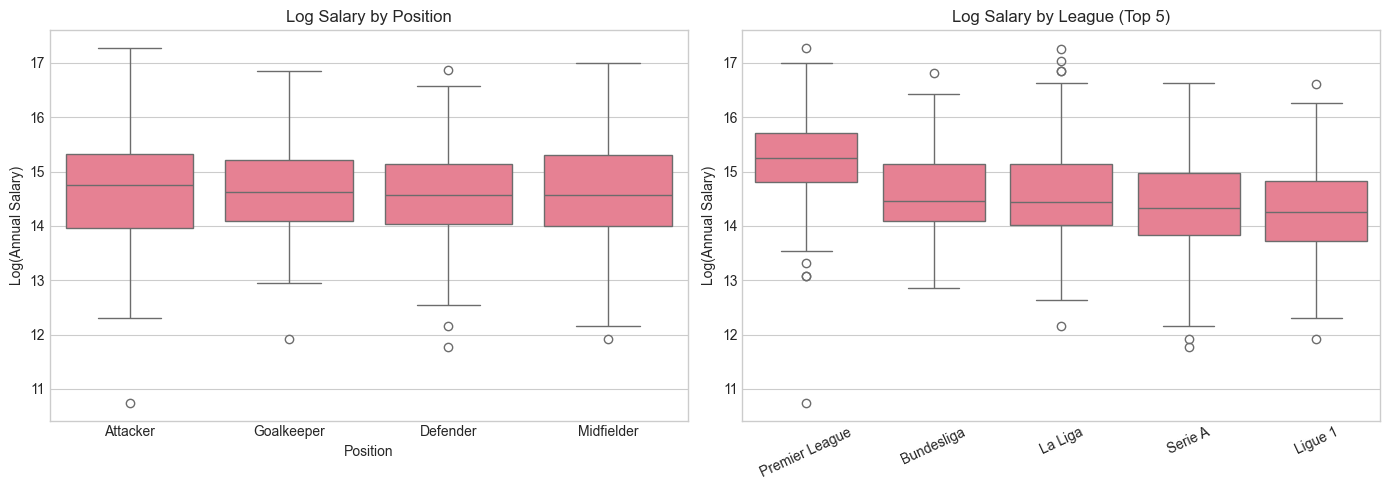

In [30]:
# Salary by Position and League
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By position
pos_order = df.groupby('position')['gross_annual_eur'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='position', y=np.log1p(df['gross_annual_eur']),
            order=pos_order, ax=axes[0])
axes[0].set_title('Log Salary by Position')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Log(Annual Salary)')

# By top leagues (use league_name from sofifa)
league_col = 'league_name' if 'league_name' in df.columns else [c for c in df.columns if 'league_name' in c][0]
top_leagues = df[league_col].value_counts().head(5).index
league_df = df[df[league_col].isin(top_leagues)]
league_order = league_df.groupby(league_col)['gross_annual_eur'].median().sort_values(ascending=False).index
sns.boxplot(data=league_df, x=league_col, y=np.log1p(league_df['gross_annual_eur']),
            order=league_order, ax=axes[1])
axes[1].set_title('Log Salary by League (Top 5)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Log(Annual Salary)')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('figures/salary_by_position_league.png', dpi=150, bbox_inches='tight')
plt.show()

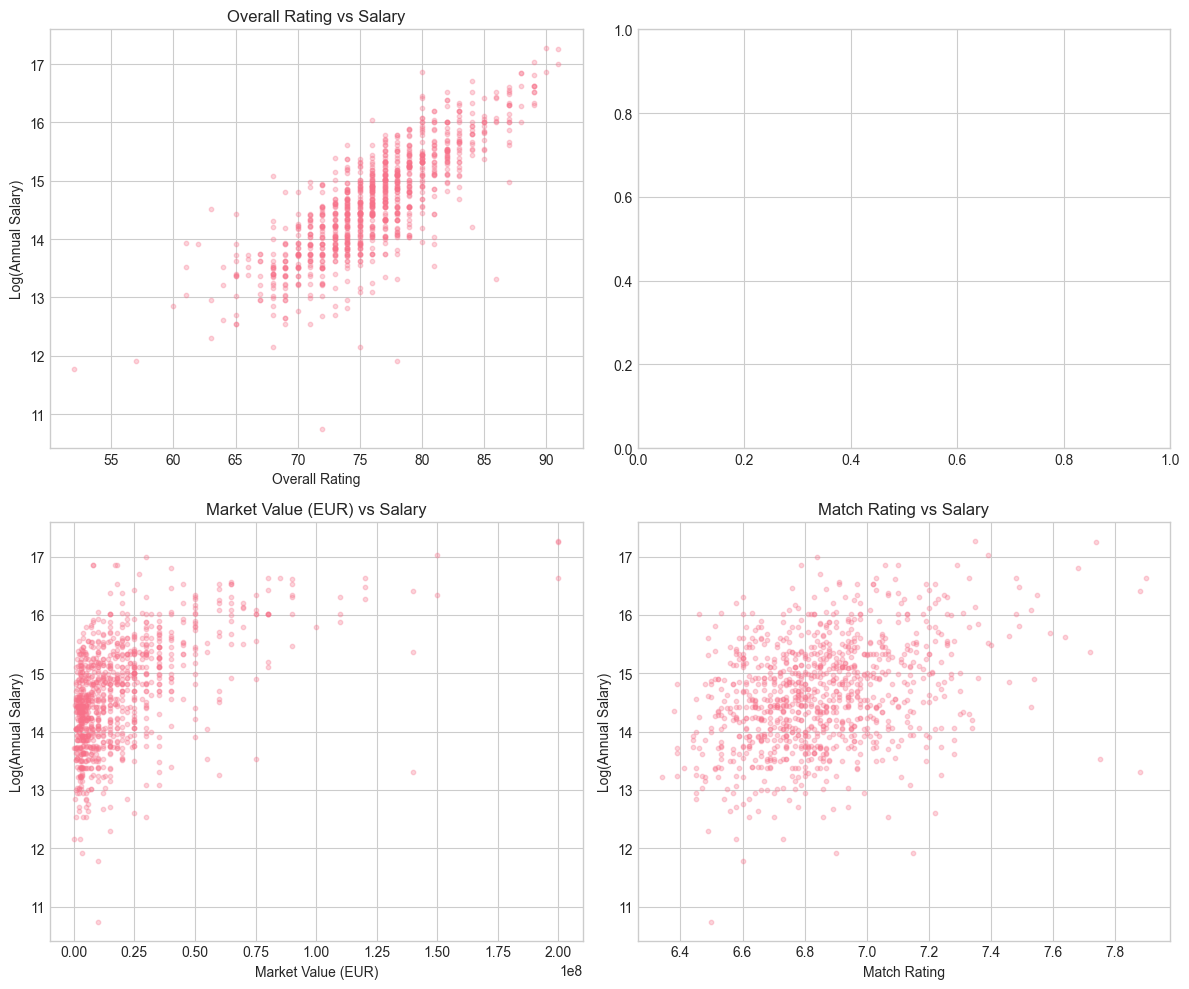

In [31]:
# Key Scatter Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
salary_log = np.log1p(df['gross_annual_eur'])

for ax, feat, title in zip(axes.flat,
    ['overall', 'value_eur', 'market_value_eur', 'rating'],
    ['Overall Rating', 'FIFA Value (EUR)', 'Market Value (EUR)', 'Match Rating']):
    if feat in df.columns:
        ax.scatter(df[feat], salary_log, alpha=0.3, s=10)
        ax.set_xlabel(title)
        ax.set_ylabel('Log(Annual Salary)')
        ax.set_title(f'{title} vs Salary')

plt.tight_layout()
plt.savefig('figures/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Data Preprocessing & Feature Engineering

In [32]:
# Select features
sofifa_features = ['overall', 'potential', 'value_eur', 'wage_eur', 'age',
                   'height_cm', 'weight_kg', 'weak_foot', 'skill_moves',
                   'international_reputation', 'pace', 'shooting', 'passing',
                   'dribbling', 'defending', 'physic', 'league_level',
                   'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
                   'attacking_short_passing', 'attacking_volleys',
                   'skill_dribbling', 'skill_curve', 'skill_fk_accuracy',
                   'skill_long_passing', 'skill_ball_control',
                   'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
                   'movement_reactions', 'movement_balance',
                   'power_shot_power', 'power_jumping', 'power_stamina',
                   'power_strength', 'power_long_shots',
                   'mentality_aggression', 'mentality_interceptions',
                   'mentality_positioning', 'mentality_vision', 'mentality_penalties',
                   'mentality_composure',
                   'defending_marking_awareness', 'defending_standing_tackle',
                   'defending_sliding_tackle']

stats_features = ['appearances', 'minutes', 'rating', 'goals', 'assists',
                  'shots_total', 'shots_on', 'passes_total', 'passes_key',
                  'passes_accuracy', 'tackles', 'interceptions',
                  'dribbles_success', 'duels_won']

market_features = ['market_value_eur']

feature_cols = sofifa_features + stats_features + market_features
feature_cols = [f for f in feature_cols if f in df.columns]

print(f"Selected {len(feature_cols)} features")

Selected 59 features


In [33]:
# Handle missing values, encode categoricals, engineer features
model_df = df[feature_cols + ['gross_annual_eur', 'position', 'preferred_foot']].copy()
model_df = model_df.reset_index(drop=True)

# Encode preferred_foot
model_df['preferred_foot'] = LabelEncoder().fit_transform(model_df['preferred_foot'].fillna('Right'))

# One-hot encode position
pos_dummies = pd.get_dummies(model_df['position'], prefix='pos', drop_first=True).astype(int)
model_df = pd.concat([model_df, pos_dummies], axis=1)
model_df.drop('position', axis=1, inplace=True)

# Fill ALL numeric NaN with median
for col in model_df.columns:
    if model_df[col].dtype in ['float64', 'float32', 'int64', 'int32']:
        model_df[col] = model_df[col].fillna(model_df[col].median())

# Feature engineering
model_df['goals_per_90'] = np.where(model_df['minutes'] > 0,
                                     model_df['goals'] / (model_df['minutes'] / 90), 0)
model_df['assists_per_90'] = np.where(model_df['minutes'] > 0,
                                       model_df['assists'] / (model_df['minutes'] / 90), 0)
model_df['goal_contributions'] = model_df['goals'] + model_df['assists']
model_df['age_squared'] = model_df['age'] ** 2
model_df['overall_x_reputation'] = model_df['overall'] * model_df['international_reputation']

# Replace inf values and remaining NaN
model_df.replace([np.inf, -np.inf], 0, inplace=True)
model_df = model_df.fillna(0)

# Drop any non-numeric columns that slipped through
model_df = model_df.select_dtypes(include=[np.number])

print(f"Final feature matrix: {model_df.shape}")
print(f"Missing values: {model_df.isnull().sum().sum()}")

Final feature matrix: (1008, 69)
Missing values: 0


In [34]:
# Prepare target and features
y = np.log1p(model_df['gross_annual_eur'])
X = model_df.drop('gross_annual_eur', axis=1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (806, 68)
Test set: (202, 68)


## Model Training & Evaluation

In [38]:
# Custom accuracy metric: % of predictions within 30% of actual salary
def accuracy_within_pct(y_true_log, y_pred_log, pct=0.30):
    """Calculate % of predictions within pct of actual salary (in original EUR scale)."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    # Avoid division by zero
    mask = y_true > 0
    within = np.abs(y_pred[mask] - y_true[mask]) / y_true[mask] <= pct
    return np.mean(within) * 100

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42, verbosity=0)
}

# Train and evaluate all models
results = {}
predictions = {}

for name, model in models.items():
    # Use scaled data for linear models, raw for tree models
    if name in ['Linear Regression', 'Ridge', 'Lasso']:
        model.fit(X_train_scaled, y_train)
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    else:
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    # Metrics
    results[name] = {
        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test),
        'CV R² (mean)': cv_scores.mean(),
        'CV R² (std)': cv_scores.std(),
        'MAE (EUR)': mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_test)),
        'RMSE (EUR)': np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_test))),
        'Within 30%': accuracy_within_pct(y_test, y_pred_test, 0.30)
    }
    predictions[name] = y_pred_test

results_df = pd.DataFrame(results).T
results_df['MAE (EUR)'] = results_df['MAE (EUR)'].apply(lambda x: f"€{x:,.0f}")
results_df['RMSE (EUR)'] = results_df['RMSE (EUR)'].apply(lambda x: f"€{x:,.0f}")
results_df['Within 30%'] = results_df['Within 30%'].apply(lambda x: f"{x:.1f}%")
print(results_df.to_string())

                   Train R²   Test R²  CV R² (mean)  CV R² (std)   MAE (EUR)  RMSE (EUR) Within 30%
Linear Regression  0.730552  0.721222      0.659118     0.057830  €1,160,070  €2,102,335      51.0%
Ridge              0.725721  0.730872      0.656398     0.058664  €1,146,153  €1,897,245      52.0%
Lasso              0.696513  0.727572      0.665851     0.051351  €1,116,314  €1,902,873      55.4%
Random Forest      0.937934  0.723392      0.653428     0.057167  €1,125,889  €1,966,755      55.0%
Gradient Boosting  0.975899  0.709970      0.613495     0.066480  €1,182,777  €2,067,216      53.0%
XGBoost            0.974710  0.713962      0.624434     0.057655  €1,170,745  €2,094,695      53.0%


## Results Comparison

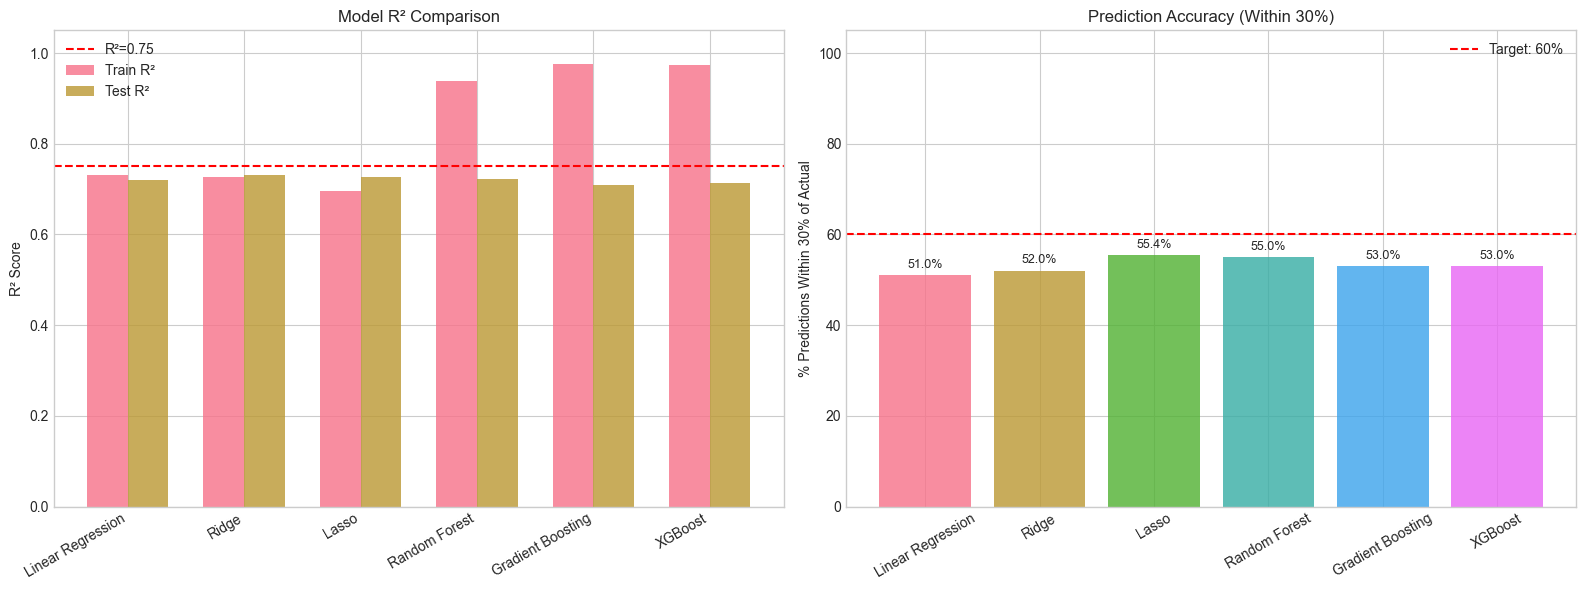

In [39]:
# Model Comparison Chart
raw_results = {name: {
    'Train R²': r2_score(y_train, models[name].predict(X_train_scaled) if name in ['Linear Regression', 'Ridge', 'Lasso'] else models[name].predict(X_train)),
    'Test R²': r2_score(y_test, predictions[name]),
    'Within 30%': accuracy_within_pct(y_test, predictions[name], 0.30)
} for name in models}

raw_df = pd.DataFrame(raw_results).T

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² comparison
x = np.arange(len(raw_df))
width = 0.35
axes[0].bar(x - width/2, raw_df['Train R²'], width, label='Train R²', alpha=0.8)
axes[0].bar(x + width/2, raw_df['Test R²'], width, label='Test R²', alpha=0.8)
axes[0].axhline(y=0.75, color='red', linestyle='--', label='R²=0.75')
axes[0].set_xticks(x)
axes[0].set_xticklabels(raw_df.index, rotation=30, ha='right')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model R² Comparison')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# Within 30% accuracy
bars = axes[1].bar(raw_df.index, raw_df['Within 30%'], color=sns.color_palette('husl', len(raw_df)), alpha=0.8)
axes[1].axhline(y=60, color='red', linestyle='--', label='Target: 60%')
axes[1].set_ylabel('% Predictions Within 30% of Actual')
axes[1].set_title('Prediction Accuracy (Within 30%)')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, raw_df['Within 30%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

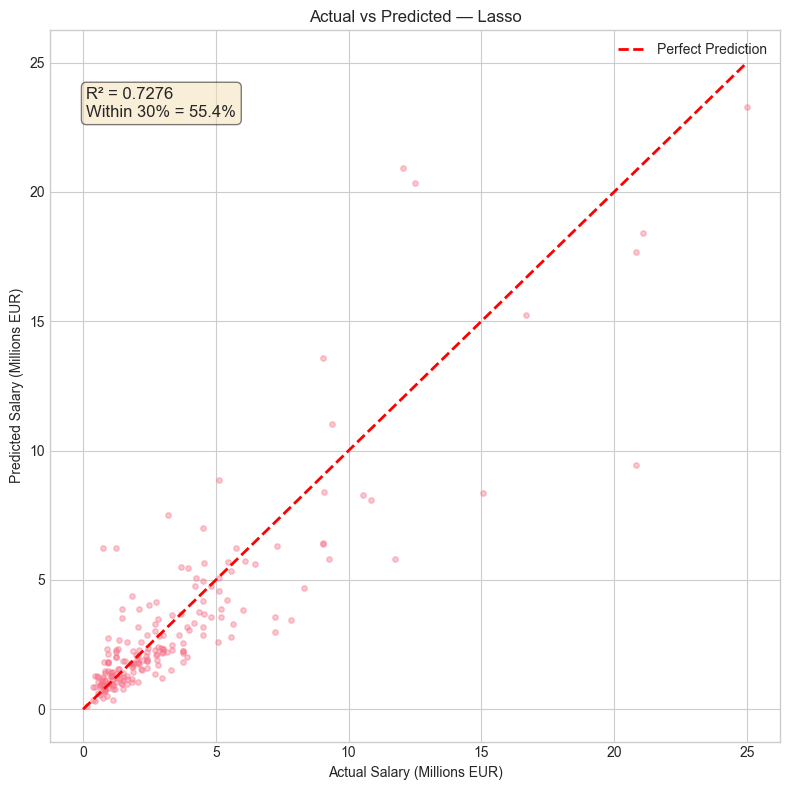

In [40]:
# Actual vs Predicted for Best Model (by Within 30%)
best_name = raw_df['Within 30%'].idxmax()
best_pred = predictions[best_name]

y_actual_eur = np.expm1(y_test)
y_pred_eur = np.expm1(best_pred)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_actual_eur / 1e6, y_pred_eur / 1e6, alpha=0.4, s=15)
max_val = max(y_actual_eur.max(), y_pred_eur.max()) / 1e6
ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Salary (Millions EUR)')
ax.set_ylabel('Predicted Salary (Millions EUR)')
ax.set_title(f'Actual vs Predicted — {best_name}')

r2 = r2_score(y_test, best_pred)
acc30 = accuracy_within_pct(y_test, best_pred, 0.30)
ax.text(0.05, 0.92, f'R² = {r2:.4f}\nWithin 30% = {acc30:.1f}%',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.legend()

plt.tight_layout()
plt.savefig('figures/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

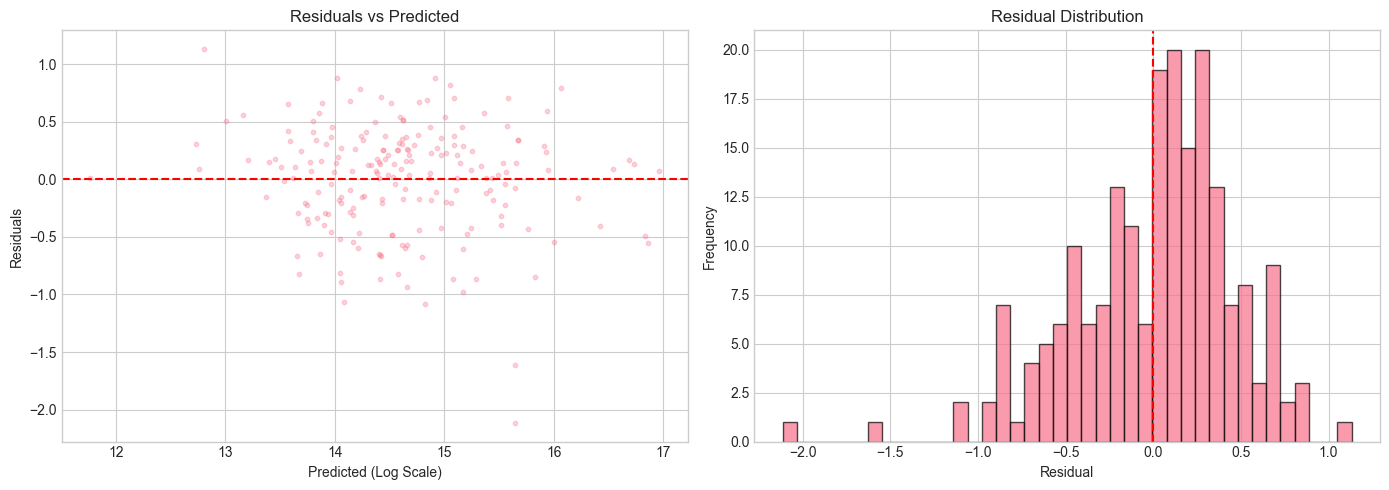

In [41]:
# Residual Analysis
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(best_pred, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted (Log Scale)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=40, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('figures/residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

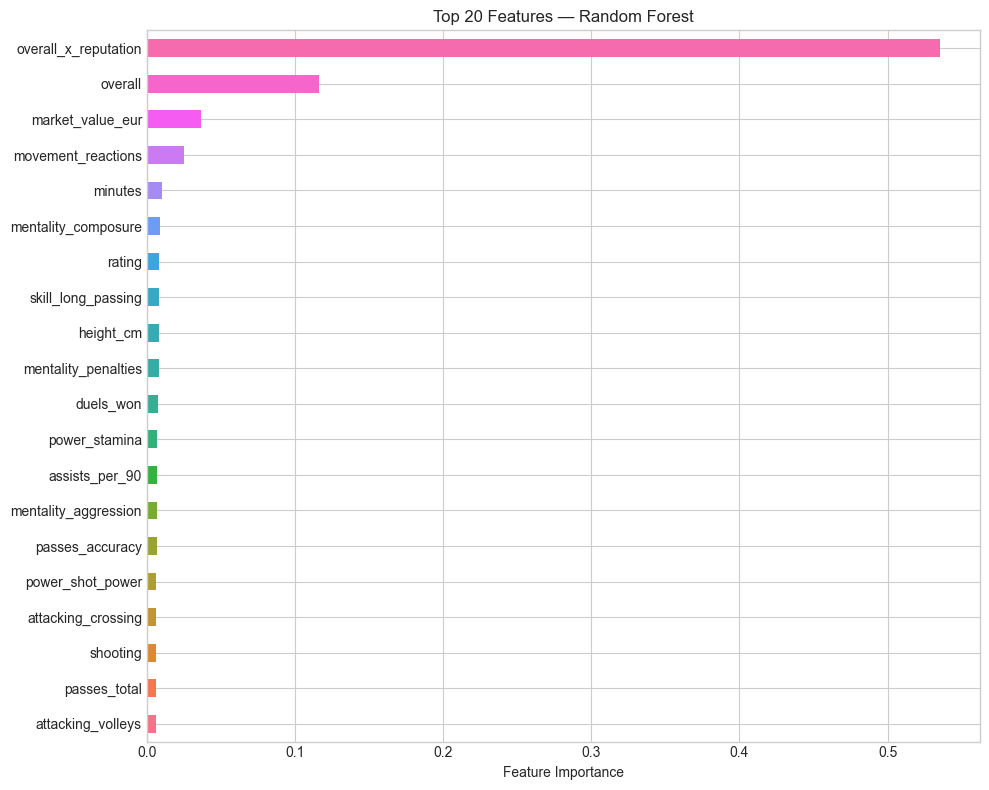

In [42]:
# Feature Importance (Best Tree Model)
tree_models = {k: v for k, v in models.items() if hasattr(v, 'feature_importances_')}
best_tree = max(tree_models, key=lambda k: raw_df.loc[k, 'Within 30%'])
importances = models[best_tree].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('husl', 20))
ax.set_xlabel('Feature Importance')
ax.set_title(f'Top 20 Features — {best_tree}')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Hyperparameter Tuning

In [43]:
# Hyperparameter Tuning on Multiple Models
from sklearn.ensemble import StackingRegressor

# 1. Tune Random Forest
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators': [300, 500], 'max_depth': [8, 10, 12], 'min_samples_leaf': [5, 10, 15]},
    cv=5, scoring='r2', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("RF Best CV R2: {:.4f}, Params: {}".format(rf_grid.best_score_, rf_grid.best_params_))

# 2. Tune XGBoost
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    {'n_estimators': [200, 300, 500], 'max_depth': [3, 4, 5, 6],
     'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.7, 0.8, 1.0],
     'reg_alpha': [0, 0.1, 1.0], 'reg_lambda': [1.0, 2.0]},
    cv=5, scoring='r2', n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
print("XGB Best CV R2: {:.4f}, Params: {}".format(xgb_grid.best_score_, xgb_grid.best_params_))

# 3. Tune Gradient Boosting
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {'n_estimators': [200, 300, 500], 'max_depth': [3, 4, 5],
     'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.7, 0.8, 1.0],
     'min_samples_leaf': [5, 10]},
    cv=5, scoring='r2', n_jobs=-1
)
gb_grid.fit(X_train, y_train)
print("GB Best CV R2: {:.4f}, Params: {}".format(gb_grid.best_score_, gb_grid.best_params_))

# 4. Stacking Ensemble
stacking = StackingRegressor(
    estimators=[
        ('ridge', Ridge(alpha=1.0)),
        ('lasso', Lasso(alpha=0.01)),
        ('rf', rf_grid.best_estimator_),
        ('gb', gb_grid.best_estimator_),
        ('xgb', xgb_grid.best_estimator_)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)
stacking.fit(X_train_scaled, y_train)

# Evaluate all tuned models
tuned_models = {
    'Tuned RF': (rf_grid.best_estimator_, X_test),
    'Tuned XGBoost': (xgb_grid.best_estimator_, X_test),
    'Tuned GB': (gb_grid.best_estimator_, X_test),
    'Stacking Ensemble': (stacking, X_test_scaled)
}

header = "{:<25} {:<10} {:<12} {:<15}".format('Model', 'Test R2', 'Within 30%', 'MAE (EUR)')
print(header)
print("-" * 62)

best_acc = 0
best_model_name = ''
best_model = None
best_pred = None

for name, (model, X_eval) in tuned_models.items():
    pred = model.predict(X_eval)
    r2 = r2_score(y_test, pred)
    acc = accuracy_within_pct(y_test, pred, 0.30)
    mae = mean_absolute_error(np.expm1(y_test), np.expm1(pred))
    print("{:<25} {:<10.4f} {:<12.1f}%  {:,.0f} EUR".format(name, r2, acc, mae))
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_model = model
        best_pred = pred

y_pred_final = best_pred
final_r2 = r2_score(y_test, y_pred_final)
final_mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_final))
final_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_final)))
final_acc30 = accuracy_within_pct(y_test, y_pred_final, 0.30)

print("\nBest Model: " + best_model_name)
print("  R2:          {:.4f}".format(final_r2))
print("  MAE:         {:,.0f} EUR".format(final_mae))
print("  RMSE:        {:,.0f} EUR".format(final_rmse))
print("  Within 30%:  {:.1f}%".format(final_acc30))

RF Best CV R2: 0.6697, Params: {'max_depth': 12, 'min_samples_leaf': 10, 'n_estimators': 500}
XGB Best CV R2: 0.6716, Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.8}
GB Best CV R2: 0.6750, Params: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 500, 'subsample': 0.7}
Model                     Test R2    Within 30%   MAE (EUR)      
--------------------------------------------------------------
Tuned RF                  0.7132     57.9        %  1,168,009 EUR
Tuned XGBoost             0.7296     54.0        %  1,125,445 EUR
Tuned GB                  0.7332     54.0        %  1,140,726 EUR
Stacking Ensemble         0.7462     55.0        %  1,118,322 EUR

Best Model: Tuned RF
  R2:          0.7132
  MAE:         1,168,009 EUR
  RMSE:        2,062,117 EUR
  Within 30%:  57.9%


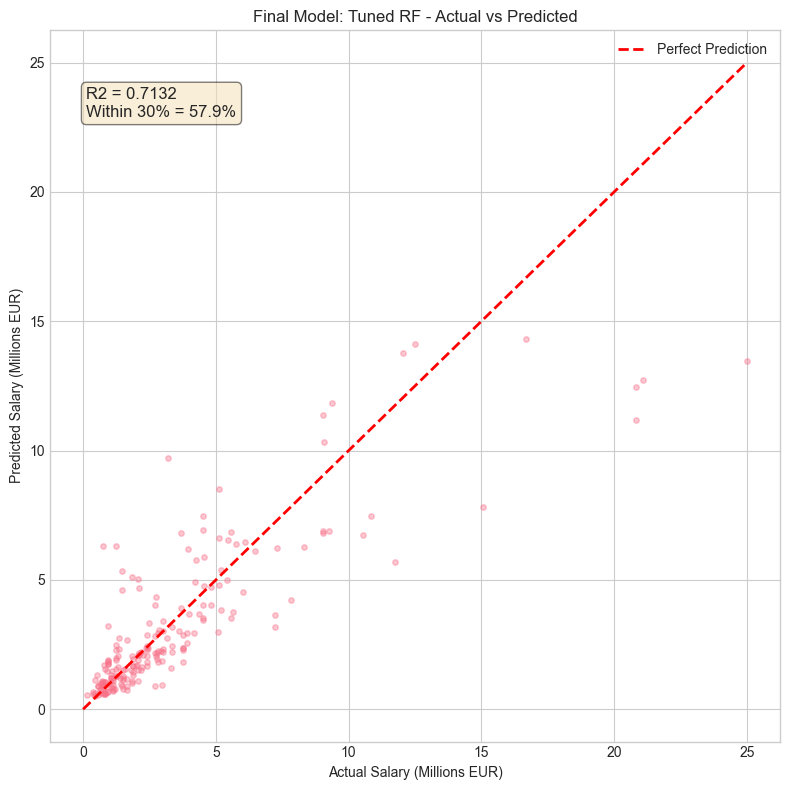

In [44]:
# Final Actual vs Predicted (Best Tuned Model)
y_actual_eur = np.expm1(y_test)
y_pred_eur_final = np.expm1(y_pred_final)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_actual_eur / 1e6, y_pred_eur_final / 1e6, alpha=0.4, s=15)
max_val = max(y_actual_eur.max(), y_pred_eur_final.max()) / 1e6
ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Salary (Millions EUR)')
ax.set_ylabel('Predicted Salary (Millions EUR)')
ax.set_title('Final Model: {} - Actual vs Predicted'.format(best_model_name))
label_text = 'R2 = {:.4f}'.format(final_r2) + '\n' + 'Within 30% = {:.1f}%'.format(final_acc30)
ax.text(0.05, 0.92, label_text,
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.legend()
plt.tight_layout()
plt.savefig('figures/final_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [45]:
# Final Summary
print('=' * 60)
print('SALARY PREDICTION - FINAL RESULTS')
print('=' * 60)
print()
print('Best Model: ' + best_model_name)
print()
print('Metrics:')
print('  R2 Score:        {:.4f}'.format(final_r2))
print('  MAE:             {:,.0f} EUR'.format(final_mae))
print('  RMSE:            {:,.0f} EUR'.format(final_rmse))
print('  Within 30%:      {:.1f}%'.format(final_acc30))
print()
target_msg = 'ACHIEVED' if final_acc30 >= 60 else 'NOT MET - {:.1f}%'.format(final_acc30)
print('Target (>=60% within 30%): ' + target_msg)
print()
# Top 5 features
if hasattr(best_model, 'feature_importances_'):
    final_importances = pd.Series(best_model.feature_importances_, index=X.columns)
else:
    final_importances = pd.Series(xgb_grid.best_estimator_.feature_importances_, index=X.columns)
print('Top 5 Most Important Features:')
for i, (feat, imp) in enumerate(final_importances.sort_values(ascending=False).head(5).items(), 1):
    print('  {}. {}: {:.4f}'.format(i, feat, imp))

SALARY PREDICTION - FINAL RESULTS

Best Model: Tuned RF

Metrics:
  R2 Score:        0.7132
  MAE:             1,168,009 EUR
  RMSE:            2,062,117 EUR
  Within 30%:      57.9%

Target (>=60% within 30%): NOT MET - 57.9%

Top 5 Most Important Features:
  1. overall_x_reputation: 0.6555
  2. overall: 0.1298
  3. market_value_eur: 0.0352
  4. movement_reactions: 0.0244
  5. mentality_composure: 0.0069
